In [1]:
from pathlib import Path
import os 
import pandas as pd

cwd = Path.cwd()

if cwd.parts[-1] != 'NonLinear_FEMSM':
    os.chdir("..")
    cwd = Path.cwd()

In [2]:
training_index = []
for item in [200,500,1000]:

    df_index = pd.read_parquet(cwd/"results"/"msm"/"seqgplvm"/f"msm_seqgplvm_{item}.parquet")
    df_index = df_index[(df_index.N==item) | (df_index.N==item/4)].reset_index(drop=True)
    #df_index = pd.read_parquet(cwd/"results"/"index"/f"training_{item}.parquet")
    #df_index = df_index[df_index.cfg_N == item*10/8].reset_index(drop=True)

    training_index.append(df_index)


In [141]:
training_index[1]

,batch_id,tau_f_seqgplvm,tau_c_seqgplvm,tau_f_seqgplvm_se,tau_c_seqgplvm_se,tau_f_seqgplvm_imp,tau_c_seqgplvm_imp,tau_f_seqgplvm_se_imp,tau_c_seqgplvm_se_imp,data_id,a,N,T,rho,p,always0,always1,subset,train_id,drop_monotone_model
0,phat_batch_1,1.939292,1.050117,0.220082,0.112006,1.941487,1.052511,0.219253,0.110289,75f923e6,2,500,10,50,4,2,14,train,000f86525f,True
1,phat_batch_2,1.415263,0.731834,0.316584,0.152030,1.420549,0.738284,0.316356,0.152442,75f923e6,2,500,10,50,4,2,14,train,000f86525f,True
2,phat_batch_3,1.312564,0.943128,0.199242,0.108293,1.317308,0.947720,0.198623,0.107487,75f923e6,2,500,10,50,4,2,14,train,000f86525f,True
3,phat_batch_4,2.586910,1.014168,0.469611,0.169534,2.588606,1.016270,0.467378,0.167125,75f923e6,2,500,10,50,4,2,14,train,000f86525f,True
4,phat_batch_5,1.590493,1.028149,0.188671,0.089572,1.593553,1.031796,0.187864,0.088507,75f923e6,2,500,10,50,4,2,14,train,000f86525f,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1211995,phat_batch_97,4.642066,-0.256698,1.297847,0.525243,4.642066,-0.256698,1.297847,0.525243,ae68a7cb,2,125,50,2,4,0,0,val,fff3b0b526,True
1211996,phat_batch_98,4.399394,-0.138459,1.090483,0.482319,4.399394,-0.138459,1.090483,0.482319,ae68a7cb,2,125,50,2,4,0,0,val,fff3b0b526,True
1211997,phat_batch_99,3.791967,-0.063383,1.473770,0.509439,3.791967,-0.063383,1.473770,0.509439,ae68a7cb,2,125,50,2,4,0,0,val,fff3b0b526,True
1211998,phat_batch_100,4.271642,-0.088754,1.361528,0.536415,4.271642,-0.088754,1.361528,0.536415,ae68a7cb,2,125,50,2,4,0,0,val,fff3b0b526,True


In [3]:
pd.concat(training_index).to_parquet(cwd/"results"/"msm"/"seqgplvm"/f"msm_seqgplvm_all.parquet")
#pd.concat(training_index).to_parquet(cwd/"results"/"index"/f"msm_seqgplvm_all.parquet")

### read seqgplvm results 


In [10]:
df_seqgplvm_results_rw = pd.read_parquet(cwd/"results"/"msm"/"seqgplvm"/"msm_seqgplvm_all.parquet")
df_seqgplvm_results_rw.head()

,batch_id,tau_f_seqgplvm,tau_c_seqgplvm,tau_f_seqgplvm_se,tau_c_seqgplvm_se,tau_f_seqgplvm_imp,tau_c_seqgplvm_imp,tau_f_seqgplvm_se_imp,tau_c_seqgplvm_se_imp,data_id,a,N,T,rho,p,always0,always1,subset,train_id,drop_monotone_model
0,phat_batch_1,1.421541,0.726641,0.242337,0.143027,1.370337,0.659141,0.236122,0.120718,4a0c7a41,1,200,4,50,2,8,40,train,0001f62a89,True
1,phat_batch_2,1.445729,0.700963,0.374278,0.175157,1.348466,0.628295,0.370659,0.161933,4a0c7a41,1,200,4,50,2,8,40,train,0001f62a89,True
2,phat_batch_3,1.367169,0.565795,0.266219,0.170852,1.340216,0.531470,0.244541,0.135850,4a0c7a41,1,200,4,50,2,8,40,train,0001f62a89,True
3,phat_batch_4,1.369913,0.853965,0.307186,0.233954,1.288582,0.779098,0.299730,0.204485,4a0c7a41,1,200,4,50,2,8,40,train,0001f62a89,True
4,phat_batch_5,0.849944,1.051657,0.354388,0.321690,0.787252,0.984465,0.347190,0.296198,4a0c7a41,1,200,4,50,2,8,40,train,0001f62a89,True


In [11]:
counts = (
    df_seqgplvm_results_rw[(df_seqgplvm_results_rw.N == 500) | (df_seqgplvm_results_rw.N == 200) | (df_seqgplvm_results_rw.N == 1000)]
    .groupby(["N","T", "a", "p", "train_id"])
    .size()
    .reset_index(name="n_rows")
)

print(counts)

          N    T  a  p    train_id  n_rows
0       200    4  1  2  000107f367     101
1       200    4  1  2  0001f62a89     101
2       200    4  1  2  00274241d6     101
3       200    4  1  2  00357e8386     101
4       200    4  1  2  009195f326     101
...     ...  ... .. ..         ...     ...
17985  1000  200  2  4  fe1b53aff3     101
17986  1000  200  2  4  fe47ff8a7e     101
17987  1000  200  2  4  fe6b62be00     101
17988  1000  200  2  4  feb8056ebb     101
17989  1000  200  2  4  ff6ae0536c     101

[17990 rows x 6 columns]


In [6]:
df_seqgplvm_results_rw = df_seqgplvm_results_rw[(df_seqgplvm_results_rw["N"].isin([200, 500, 1000])) & (df_seqgplvm_results_rw["batch_id"]== "phat_mean")].reset_index(drop=True)

df_seqgplvm_results = (
    df_seqgplvm_results_rw
    .loc[df_seqgplvm_results_rw["N"].isin([200, 500, 1000])]
    .groupby(["N", "T", "a", "p", "train_id"], as_index=False)
    .agg(
        tau_f_seqgplvm      = ("tau_f_seqgplvm", "mean"),
        tau_f_seqgplvm_se   = ("tau_f_seqgplvm_se", "mean"),
        tau_c_seqgplvm      = ("tau_c_seqgplvm", "mean"),
        tau_c_seqgplvm_se   = ("tau_c_seqgplvm_se", "mean"),
        tau_f_seqgplvm_imp    = ("tau_f_seqgplvm_imp", "mean"),
        tau_f_seqgplvm_imp_se = ("tau_f_seqgplvm_se_imp", "mean"),
        tau_c_seqgplvm_imp    = ("tau_c_seqgplvm_imp", "mean"),
        tau_c_seqgplvm_imp_se = ("tau_c_seqgplvm_se_imp", "mean"),
    )
)
df_seqgplvm_results["seed"] = pd.NA


df_seqgplvm_results["seed"] = (
    df_seqgplvm_results
    .groupby(["N", "T", "a", "p"])
    .cumcount() + 1
)

In [7]:
df_seqgplvm_results

,N,T,a,p,train_id,tau_f_seqgplvm,tau_f_seqgplvm_se,tau_c_seqgplvm,tau_c_seqgplvm_se,tau_f_seqgplvm_imp,tau_f_seqgplvm_imp_se,tau_c_seqgplvm_imp,tau_c_seqgplvm_imp_se,seed
0,200,4,1,2,000107f367,1.071859,0.222156,0.517205,0.142166,0.985355,0.200698,0.441079,0.116824,1
1,200,4,1,2,0001f62a89,1.426802,0.230009,0.622790,0.155741,1.375151,0.217420,0.563479,0.124787,2
2,200,4,1,2,00274241d6,1.597533,0.263490,0.716414,0.158142,1.478192,0.242696,0.577691,0.124638,3
3,200,4,1,2,00357e8386,1.468970,0.283456,0.481392,0.184329,1.417088,0.255532,0.424571,0.152030,4
4,200,4,1,2,009195f326,1.509562,0.260167,0.716520,0.300976,1.430942,0.255887,0.642554,0.256934,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17985,1000,200,2,4,fe1b53aff3,0.479202,0.341904,0.589702,0.108963,0.479202,0.341904,0.589702,0.108963,492
17986,1000,200,2,4,fe47ff8a7e,0.946951,0.270705,0.337397,0.128131,0.946951,0.270705,0.337397,0.128131,493
17987,1000,200,2,4,fe6b62be00,1.025906,0.334794,0.399816,0.169528,1.025906,0.334794,0.399816,0.169528,494
17988,1000,200,2,4,feb8056ebb,1.527911,0.199569,0.567575,0.104183,1.527911,0.199569,0.567575,0.104183,495


In [12]:
df_seqgplvm_results_rw = df_seqgplvm_results_rw[df_seqgplvm_results_rw.batch_id != "phat_mean"].reset_index(drop=True)
df_seqgplvm_results = (
    df_seqgplvm_results_rw
    .loc[df_seqgplvm_results_rw["N"].isin([200, 500, 1000])]
    .groupby(["N", "T", "a", "p", "train_id"], as_index=False)
    .agg(
        tau_f_seqgplvm      = ("tau_f_seqgplvm", "mean"),
        tau_f_seqgplvm_se   = ("tau_f_seqgplvm_se", "mean"),
        tau_c_seqgplvm      = ("tau_c_seqgplvm", "mean"),
        tau_c_seqgplvm_se   = ("tau_c_seqgplvm_se", "mean"),
        tau_f_seqgplvm_imp    = ("tau_f_seqgplvm_imp", "mean"),
        tau_f_seqgplvm_imp_se = ("tau_f_seqgplvm_se_imp", "mean"),
        tau_c_seqgplvm_imp    = ("tau_c_seqgplvm_imp", "mean"),
        tau_c_seqgplvm_imp_se = ("tau_c_seqgplvm_se_imp", "mean"),
    )
)
df_seqgplvm_results["seed"] = pd.NA


df_seqgplvm_results["seed"] = (
    df_seqgplvm_results
    .groupby(["N", "T", "a", "p"])
    .cumcount() + 1
)

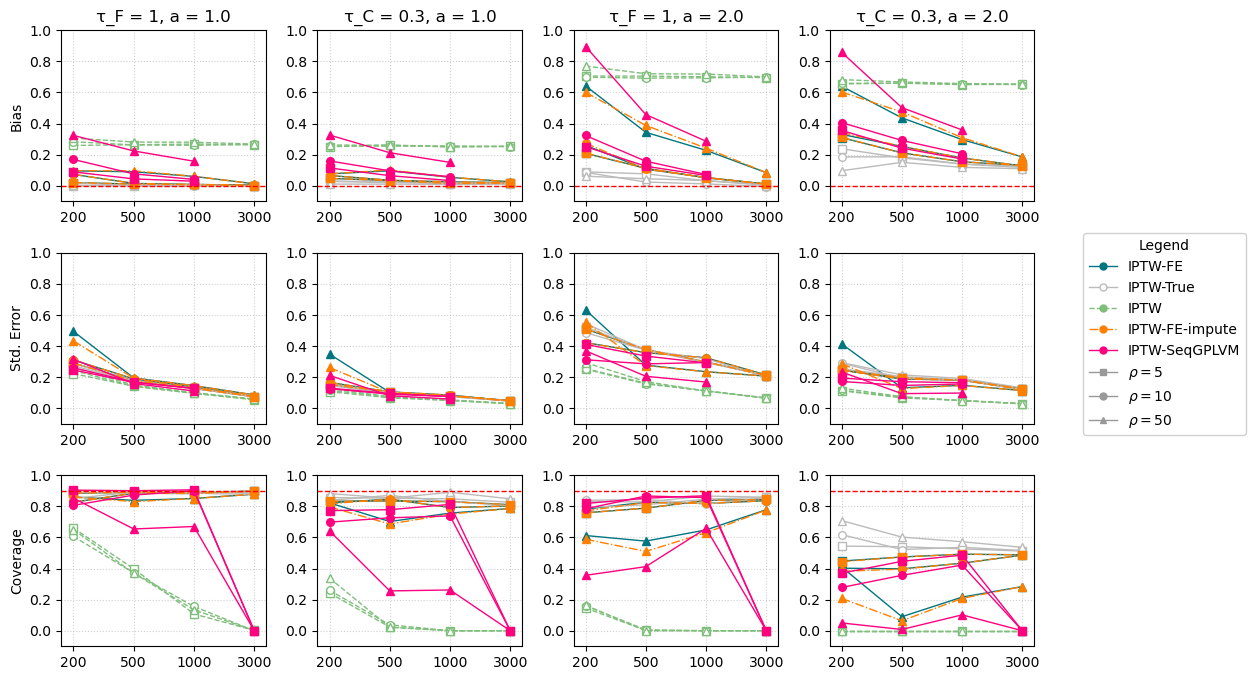

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import norm

df_results = pd.read_csv(cwd/"results"/"msm"/"fe_msm_results_monotone_included.csv")
df_results["tau_c"] = 0.3
df_results["tau_f"] = 1.0

z_90 = norm.ppf(0.95)

# -----------------------------------
# 1) Prepare long data with tau_hats
# -----------------------------------

# NEW: keep both a = 1 and a = 2 (only filter on p)
dfp = df_results.loc[(df_results.p == 2)].copy()
dfp = dfp.drop(columns=["data_id"]).merge(
    df_seqgplvm_results,
    on=["N", "T", "a", "p", "seed"],
    how="left",
)

methods = ["IPTW-FE", "IPTW-True", "IPTW", "IPTW-FE-impute", "IPTW-SeqGPLVM"]

tau_f_cols = {
    "IPTW-FE":   "tau_f_fe",
    "IPTW-True": "tau_f_true",
    "IPTW":      "tau_f_no_fe",
    "IPTW-FE-impute":      "tau_f_fe_impute",
    "IPTW-SeqGPLVM": "tau_f_seqgplvm",  
}
tau_c_cols = {
    "IPTW-FE":   "tau_c_fe",
    "IPTW-True": "tau_c_true",
    "IPTW":      "tau_c_no_fe",
    "IPTW-FE-impute":      "tau_c_fe_impute",
    "IPTW-SeqGPLVM": "tau_c_seqgplvm",
}

rows = []
for _, r in dfp.iterrows():
    for m in methods:
        # τ_F
        rows.append({
            "a":       r["a"],          # NEW: keep a
            "N":       r["N"],
            "rho":     r["rho"],
            "param":   "τ_F = 1",
            "method":  m,
            "tau_hat": r[tau_f_cols[m]],
            "tau_true": r["tau_f"],
            "seed":    r["seed"],
            "se_hat":  r[{"IPTW-FE":"tau_f_fe_se",
                         "IPTW-True":"tau_f_true_se",
                         "IPTW":"tau_f_no_fe_se",
                         "IPTW-FE-impute": "tau_f_fe_impute_se",
                        "IPTW-SeqGPLVM": "tau_f_seqgplvm_se",
                         }[m]]
        })
        # τ_C
        rows.append({
            "a":       r["a"],          
            "N":       r["N"],
            "rho":     r["rho"],
            "param":   "τ_C = 0.3",
            "method":  m,
            "tau_hat": r[tau_c_cols[m]],
            "tau_true": r["tau_c"],
            "seed":    r["seed"],
            "se_hat":  r[{"IPTW-FE":"tau_c_fe_se",
                         "IPTW-True":"tau_c_true_se",
                         "IPTW":"tau_c_no_fe_se",
                         "IPTW-FE-impute": "tau_c_fe_impute_se", 
                         "IPTW-SeqGPLVM": "tau_c_seqgplvm_se",
                         }[m]]
        })

long_df = pd.DataFrame(rows).sort_values(["a", "param", "method", "rho", "N"])

# diffs per simulation
long_df["diff"] = long_df["tau_hat"] - long_df["tau_true"]
long_df["abs_diff"] = long_df["diff"].abs()

# 90% Wald CI using HC2 SEs
long_df["ci_low"]  = long_df["tau_hat"] - z_90 * long_df["se_hat"]
long_df["ci_high"] = long_df["tau_hat"] + z_90 * long_df["se_hat"]
long_df["covered"] = (
    (long_df["tau_true"] >= long_df["ci_low"]) &
    (long_df["tau_true"] <= long_df["ci_high"])
).astype(float)

# -----------------------------------
# 2) Aggregate over seeds
# -----------------------------------
agg_df = (
    long_df
    .groupby(["a", "N", "rho", "param", "method"], as_index=False)  # NEW: include a
    .agg(
        bias_abs=("abs_diff", "mean"),   # mean |bias|
        std_tau=("tau_hat", "std"),      # MC std of estimator
        bias = ("diff", "mean"),         # mean bias
        coverage = ("covered", "mean")
    )
)

# -----------------------------------
# 3) Plot: 3 rows (bias, std, coverage) × 4 cols (a=1,2 × τ_F, τ_C)
# -----------------------------------
method_ls    = {"IPTW-FE": "-", "IPTW-True": "-", "IPTW": "--", "IPTW-FE-impute": "-.", "IPTW-SeqGPLVM": "-"}
method_color = {"IPTW-FE": "#007680", "IPTW-True": "#BBBBBB", "IPTW": "#7FBF7B", "IPTW-FE-impute": "#FF7F00", "IPTW-SeqGPLVM": "#FF007F"}
rho_markers  = {5: "s", 10: "o", 50: "^"}

# NEW: 3 rows x 4 columns
fig, axes = plt.subplots(3, 4, figsize=(14, 8), sharex=False, sharey=False)

params = ["τ_F = 1", "τ_C = 0.3"]
a_vals = sorted(agg_df["a"].unique())   # expects [1, 2]

unique_N = sorted(agg_df["N"].unique())
xpos = {n: i for i, n in enumerate(unique_N)}

rowspecs = [
    (0, "bias",      "Bias"),
    (1, "std_tau",   "Std. Error"),
    (2, "coverage",  "Coverage"),
]

for row_idx, metric_col, ylabel in rowspecs:
    for a_idx, a_val in enumerate(a_vals):
        for p_idx, param in enumerate(params):
            col_idx = 2 * a_idx + p_idx   # 0,1 -> a=1 ; 2,3 -> a=2
            ax = axes[row_idx, col_idx]

            # subset for this (a, param)
            sub = agg_df[(agg_df["a"] == a_val) & (agg_df["param"] == param)]

            for method in methods:
                for rho, g in sub[sub["method"] == method].groupby("rho"):
                    x = g["N"].map(xpos)
                    ax.plot(
                        x,
                        g[metric_col],
                        linestyle=method_ls[method],
                        color=method_color[method],
                        marker=rho_markers.get(rho, "o"),
                        markerfacecolor=(
                            "white" if method in ("IPTW-True", "IPTW") else method_color[method]
                        ),
                        lw=1,
                        markersize=5.5,
                    )

            ax.set_xticks(range(len(unique_N)))
            ax.set_xticklabels(unique_N)
            ax.set_xlim(-0.2, len(unique_N) - 0.8)
            # Only left-most column gets a y-label
            if col_idx == 0:
                ax.set_ylabel(ylabel)
            else:
                ax.set_ylabel("")
           

            if row_idx == 0:
                # NEW: title shows param and a
                ax.set_title(f"{param}, a = {a_val}")

            ax.grid(True, linestyle=":", alpha=0.6)

            # Horizontal reference lines
            if metric_col == "bias":
                # zero bias
                ax.axhline(0.0, color="red", linestyle="--", linewidth=1)
            elif metric_col == "coverage":
                # nominal 90% coverage
                ax.axhline(0.9, color="red", linestyle="--", linewidth=1)


            # Optional: nicer y-limits for coverage vs others
            
            ax.set_ylim(-0.1, 1)

# -----------------------------------
# 4) One combined legend outside
# -----------------------------------
method_handles = [
    Line2D([0],[0], color=method_color["IPTW-FE"],   linestyle="-",  marker="o", lw=1, markersize=5, label="IPTW-FE"),
    Line2D([0],[0], color=method_color["IPTW-True"], linestyle="-",  marker="o", lw=1, markersize=5,
           markerfacecolor="white", label="IPTW-True"),
    Line2D([0],[0], color=method_color["IPTW"],      linestyle="--", marker="o", lw=1, markersize=5, label="IPTW"),
    Line2D([0],[0], color=method_color["IPTW-FE-impute"],      linestyle="-.", marker="o", lw=1, markersize=5, label="IPTW-FE-impute"),
    Line2D([0],[0], color=method_color["IPTW-SeqGPLVM"],      linestyle="-", marker="o", lw=1, markersize=5, label="IPTW-SeqGPLVM"),
]
shape_handles = [
    Line2D([0],[0], color="0.6", linestyle="-", marker="s", lw=1, markersize=5, label=r"$\rho=5$"),
    Line2D([0],[0], color="0.6", linestyle="-", marker="o", lw=1, markersize=5, label=r"$\rho=10$"),
    Line2D([0],[0], color="0.6", linestyle="-", marker="^", lw=1, markersize=5, label=r"$\rho=50$"),
]
all_handles = method_handles + shape_handles
all_labels  = [h.get_label() for h in all_handles]

fig.legend(
    all_handles, all_labels,
    loc="center left", bbox_to_anchor=(0.85, 0.5),
    frameon=True, fancybox=True, framealpha=0.9,
    title="Legend", ncol=1,
)

fig.subplots_adjust(right=0.82, hspace=0.3, wspace=0.25)
plt.show()


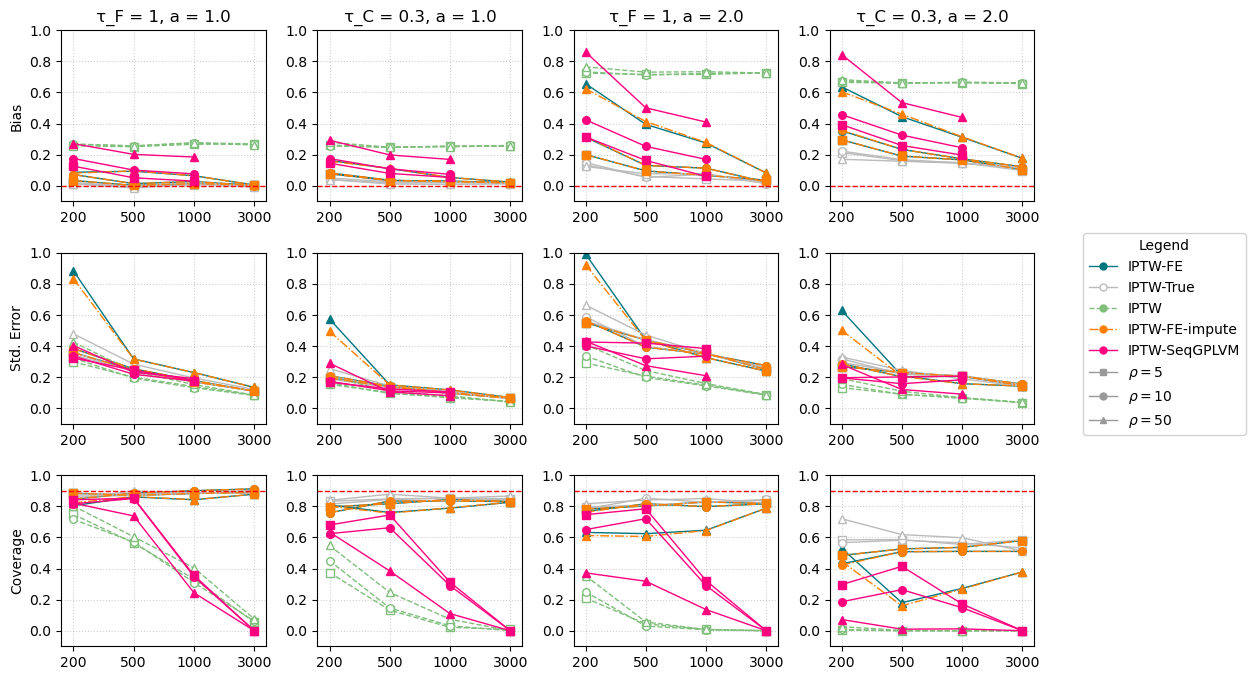

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import norm

df_results = pd.read_csv(cwd/"results"/"msm"/"fe_msm_results_monotone_included.csv")
df_results["tau_c"] = 0.3
df_results["tau_f"] = 1.0

z_90 = norm.ppf(0.95)

# -----------------------------------
# 1) Prepare long data with tau_hats
# -----------------------------------

# NEW: keep both a = 1 and a = 2 (only filter on p)
dfp = df_results.loc[(df_results.p == 4)].copy()
dfp = dfp.drop(columns=["data_id"]).merge(
    df_seqgplvm_results,
    on=["N", "T", "a", "p", "seed"],
    how="left",
)

methods = ["IPTW-FE", "IPTW-True", "IPTW", "IPTW-FE-impute", "IPTW-SeqGPLVM"]

tau_f_cols = {
    "IPTW-FE":   "tau_f_fe",
    "IPTW-True": "tau_f_true",
    "IPTW":      "tau_f_no_fe",
    "IPTW-FE-impute":      "tau_f_fe_impute",
    "IPTW-SeqGPLVM": "tau_f_seqgplvm",  
}
tau_c_cols = {
    "IPTW-FE":   "tau_c_fe",
    "IPTW-True": "tau_c_true",
    "IPTW":      "tau_c_no_fe",
    "IPTW-FE-impute":      "tau_c_fe_impute",
    "IPTW-SeqGPLVM": "tau_c_seqgplvm",
}

rows = []
for _, r in dfp.iterrows():
    for m in methods:
        # τ_F
        rows.append({
            "a":       r["a"],          # NEW: keep a
            "N":       r["N"],
            "rho":     r["rho"],
            "param":   "τ_F = 1",
            "method":  m,
            "tau_hat": r[tau_f_cols[m]],
            "tau_true": r["tau_f"],
            "seed":    r["seed"],
            "se_hat":  r[{"IPTW-FE":"tau_f_fe_se",
                         "IPTW-True":"tau_f_true_se",
                         "IPTW":"tau_f_no_fe_se",
                         "IPTW-FE-impute": "tau_f_fe_impute_se",
                        "IPTW-SeqGPLVM": "tau_f_seqgplvm_se",
                         }[m]]
        })
        # τ_C
        rows.append({
            "a":       r["a"],          
            "N":       r["N"],
            "rho":     r["rho"],
            "param":   "τ_C = 0.3",
            "method":  m,
            "tau_hat": r[tau_c_cols[m]],
            "tau_true": r["tau_c"],
            "seed":    r["seed"],
            "se_hat":  r[{"IPTW-FE":"tau_c_fe_se",
                         "IPTW-True":"tau_c_true_se",
                         "IPTW":"tau_c_no_fe_se",
                         "IPTW-FE-impute": "tau_c_fe_impute_se", 
                         "IPTW-SeqGPLVM": "tau_c_seqgplvm_se",
                         }[m]]
        })

long_df = pd.DataFrame(rows).sort_values(["a", "param", "method", "rho", "N"])

# diffs per simulation
long_df["diff"] = long_df["tau_hat"] - long_df["tau_true"]
long_df["abs_diff"] = long_df["diff"].abs()

# 90% Wald CI using HC2 SEs
long_df["ci_low"]  = long_df["tau_hat"] - z_90 * long_df["se_hat"]
long_df["ci_high"] = long_df["tau_hat"] + z_90 * long_df["se_hat"]
long_df["covered"] = (
    (long_df["tau_true"] >= long_df["ci_low"]) &
    (long_df["tau_true"] <= long_df["ci_high"])
).astype(float)

# -----------------------------------
# 2) Aggregate over seeds
# -----------------------------------
agg_df = (
    long_df
    .groupby(["a", "N", "rho", "param", "method"], as_index=False)  # NEW: include a
    .agg(
        bias_abs=("abs_diff", "mean"),   # mean |bias|
        std_tau=("tau_hat", "std"),      # MC std of estimator
        bias = ("diff", "mean"),         # mean bias
        coverage = ("covered", "mean")
    )
)

# -----------------------------------
# 3) Plot: 3 rows (bias, std, coverage) × 4 cols (a=1,2 × τ_F, τ_C)
# -----------------------------------
method_ls    = {"IPTW-FE": "-", "IPTW-True": "-", "IPTW": "--", "IPTW-FE-impute": "-.", "IPTW-SeqGPLVM": "-"}
method_color = {"IPTW-FE": "#007680", "IPTW-True": "#BBBBBB", "IPTW": "#7FBF7B", "IPTW-FE-impute": "#FF7F00", "IPTW-SeqGPLVM": "#FF007F"}
rho_markers  = {5: "s", 10: "o", 50: "^"}

# NEW: 3 rows x 4 columns
fig, axes = plt.subplots(3, 4, figsize=(14, 8), sharex=False, sharey=False)

params = ["τ_F = 1", "τ_C = 0.3"]
a_vals = sorted(agg_df["a"].unique())   # expects [1, 2]

unique_N = sorted(agg_df["N"].unique())
xpos = {n: i for i, n in enumerate(unique_N)}

rowspecs = [
    (0, "bias",      "Bias"),
    (1, "std_tau",   "Std. Error"),
    (2, "coverage",  "Coverage"),
]

for row_idx, metric_col, ylabel in rowspecs:
    for a_idx, a_val in enumerate(a_vals):
        for p_idx, param in enumerate(params):
            col_idx = 2 * a_idx + p_idx   # 0,1 -> a=1 ; 2,3 -> a=2
            ax = axes[row_idx, col_idx]

            # subset for this (a, param)
            sub = agg_df[(agg_df["a"] == a_val) & (agg_df["param"] == param)]

            for method in methods:
                for rho, g in sub[sub["method"] == method].groupby("rho"):
                    x = g["N"].map(xpos)
                    ax.plot(
                        x,
                        g[metric_col],
                        linestyle=method_ls[method],
                        color=method_color[method],
                        marker=rho_markers.get(rho, "o"),
                        markerfacecolor=(
                            "white" if method in ("IPTW-True", "IPTW") else method_color[method]
                        ),
                        lw=1,
                        markersize=5.5,
                    )

            ax.set_xticks(range(len(unique_N)))
            ax.set_xticklabels(unique_N)
            ax.set_xlim(-0.2, len(unique_N) - 0.8)
            # Only left-most column gets a y-label
            if col_idx == 0:
                ax.set_ylabel(ylabel)
            else:
                ax.set_ylabel("")
           

            if row_idx == 0:
                # NEW: title shows param and a
                ax.set_title(f"{param}, a = {a_val}")

            ax.grid(True, linestyle=":", alpha=0.6)

            # Horizontal reference lines
            if metric_col == "bias":
                # zero bias
                ax.axhline(0.0, color="red", linestyle="--", linewidth=1)
            elif metric_col == "coverage":
                # nominal 90% coverage
                ax.axhline(0.9, color="red", linestyle="--", linewidth=1)


            # Optional: nicer y-limits for coverage vs others
            
            ax.set_ylim(-0.1, 1)

# -----------------------------------
# 4) One combined legend outside
# -----------------------------------
method_handles = [
    Line2D([0],[0], color=method_color["IPTW-FE"],   linestyle="-",  marker="o", lw=1, markersize=5, label="IPTW-FE"),
    Line2D([0],[0], color=method_color["IPTW-True"], linestyle="-",  marker="o", lw=1, markersize=5,
           markerfacecolor="white", label="IPTW-True"),
    Line2D([0],[0], color=method_color["IPTW"],      linestyle="--", marker="o", lw=1, markersize=5, label="IPTW"),
    Line2D([0],[0], color=method_color["IPTW-FE-impute"],      linestyle="-.", marker="o", lw=1, markersize=5, label="IPTW-FE-impute"),
    Line2D([0],[0], color=method_color["IPTW-SeqGPLVM"],      linestyle="-", marker="o", lw=1, markersize=5, label="IPTW-SeqGPLVM"),
]
shape_handles = [
    Line2D([0],[0], color="0.6", linestyle="-", marker="s", lw=1, markersize=5, label=r"$\rho=5$"),
    Line2D([0],[0], color="0.6", linestyle="-", marker="o", lw=1, markersize=5, label=r"$\rho=10$"),
    Line2D([0],[0], color="0.6", linestyle="-", marker="^", lw=1, markersize=5, label=r"$\rho=50$"),
]
all_handles = method_handles + shape_handles
all_labels  = [h.get_label() for h in all_handles]

fig.legend(
    all_handles, all_labels,
    loc="center left", bbox_to_anchor=(0.85, 0.5),
    frameon=True, fancybox=True, framealpha=0.9,
    title="Legend", ncol=1,
)

fig.subplots_adjust(right=0.82, hspace=0.3, wspace=0.25)
plt.show()


In [98]:
df_seqgplvm_results

,N,T,a,p,train_id,tau_f_seqgplvm,tau_f_seqgplvm_se,tau_c_seqgplvm,tau_c_seqgplvm_se,tau_f_seqgplvm_imp,tau_f_seqgplvm_imp_se,tau_c_seqgplvm_imp,tau_c_seqgplvm_imp_se,seed
0,200,4,1,2,0001f62a89,1.375014,0.349386,0.659445,0.248487,1.330352,0.335615,0.614841,0.213713,1
1,200,4,1,2,009195f326,1.493195,0.362911,0.859824,0.364067,1.426907,0.358286,0.795563,0.325270,2
2,200,4,1,2,01abddd577,1.080008,0.342269,0.701927,0.245218,1.062366,0.347480,0.683190,0.200023,3
3,200,4,1,2,01ea7881e0,1.883198,0.433319,0.734893,0.268042,1.779188,0.417209,0.625806,0.235171,4
4,200,4,1,2,02fa7def68,1.844260,0.352399,0.925553,0.208201,1.748892,0.341336,0.836379,0.191708,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7185,1000,200,2,4,fb912f2ef2,1.428518,0.217656,0.340882,0.153466,1.428518,0.217656,0.340882,0.153466,192
7186,1000,200,2,4,fb93eb0be0,0.957047,0.301089,0.449017,0.176590,0.957047,0.301089,0.449017,0.176590,193
7187,1000,200,2,4,fd09bb3cfa,1.201885,0.250541,0.490730,0.110539,1.201885,0.250541,0.490730,0.110539,194
7188,1000,200,2,4,fe47ff8a7e,0.900632,0.290666,0.312435,0.137075,0.900632,0.290666,0.312435,0.137075,195
